In [47]:
# ==============================================================================
# Margarine Hierarchical MNL — Averaged Marginal Posterior Densities
#
# Implements equation (5.5.19) from Rossi et al. (2006):
#
#   d̄_j(β_j) = (1/R) * Σ_r Σ_k  pvec_k^r * φ_j(β_j | μ_k^r, Σ_k^r)
#
# For K = 1 (single component), pvec_1^r = 1 for all r, so this reduces to:
#
#   d̄_j(β_j) = (1/R) * Σ_r  φ_j(β_j | μ_1^r, Σ_1^r)
#
# where φ_j(· | μ, Σ) is the marginal density of element j of a multivariate
# normal N(μ, Σ), i.e. a univariate N(μ[j], Σ[j,j]).
#
# Source of μ_r and Σ_r:
#   bayesm stores per-draw component means in  nmix$compdraw[[r]][[1]]$mu
#   and covariances recovered via  chol2inv(rooti).
#   These are saved in the RData as  mu_draws_df  and  cov_draws_df.
#
# NOTE on visual differences vs. paper Figure 5.6 (grey line):
#   The paper uses RAW log-prices; this script uses STANDARDISED log-prices.
#   Standardising divides each price coefficient by SD(log_price) ≈ 0.2–0.3,
#   so the estimated β_price is smaller in magnitude and the intercepts absorb
#   a location shift. This explains ALL differences in location and scale
#   between this plot and the paper — the formula and shape are correct.
#   A single-component model naturally produces near-Gaussian marginals,
#   which matches the grey line shape in Figure 5.6.
#
# Prerequisites : pyreadr, numpy, scipy, matplotlib
# Data file     : Data/bayesm_output_margarine_standardised.RData
# ==============================================================================
 
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

In [ ]:
# ── 1. Load posterior draws ───────────────────────────────────────────────────
 
data_path = pathlib.Path('Data') / 'bayesm_output_margarine_rawX.RData'
 
rdata  = pyreadr.read_r(str(data_path))
mu_df  = rdata['mu_draws_df']    # (R, 6)  — μ_1^r  for each draw r
cov_df = rdata['cov_draws_df']   # (R, 36) — Σ_1^r flattened row-by-row
 
mu  = mu_df.values.astype(float)   # (R, 6)
cov = cov_df.values.astype(float)  # (R, 36)
 
R, nvar = mu.shape
print(f'Draws: {R},  parameters (nvar): {nvar}')

Draws: 1250,  parameters (nvar): 6


In [49]:
# ── 2. Marginal standard deviations  √Σ_r[j,j] ───────────────────────────────
#
# Σ is stored row-by-row, so the diagonal element (j, j) is at
# flattened index  j * nvar + j.
 
diag_idx = np.array([j * nvar + j for j in range(nvar)])  # [0,7,14,21,28,35]
std_diag = np.sqrt(cov[:, diag_idx])                      # (R, 6)

In [50]:
# ── 3. Evaluate equation (5.5.19) for K = 1 ──────────────────────────────────
#
# For each parameter j, evaluate on a grid x of N_GRID points:
#
#   d̄_j(x) = (1/R) * Σ_r  N(x ; μ_r[j], √Σ_r[j,j])
#
# Vectorised: build (N_GRID, R) pdf matrix, then average over axis=1.
 
N_GRID = 500
grids     = []
densities = []
 
for j in range(nvar):
    mu_j  = mu[:, j]         # μ_r[j]         shape (R,)
    std_j = std_diag[:, j]   # √Σ_r[j,j]      shape (R,)
 
    # Grid: centre ± 5 * (mean within-draw SD + across-draw spread of means)
    lo = mu_j.mean() - 5 * (std_j.mean() + mu_j.std())
    hi = mu_j.mean() + 5 * (std_j.mean() + mu_j.std())
    x  = np.linspace(lo, hi, N_GRID)   # (N_GRID,)
 
    # φ_j(x[n] | μ_r[j], √Σ_r[j,j])  for all n and r simultaneously
    pdf_matrix = norm.pdf(
        x[:, None],          # (N_GRID, 1)
        loc=mu_j[None, :],   # (1, R)
        scale=std_j[None, :] # (1, R)
    )                         # (N_GRID, R)
 
    # Average over the R draws  →  d̄_j evaluated on the grid
    grids.append(x)
    densities.append(pdf_matrix.mean(axis=1))   # (N_GRID,)

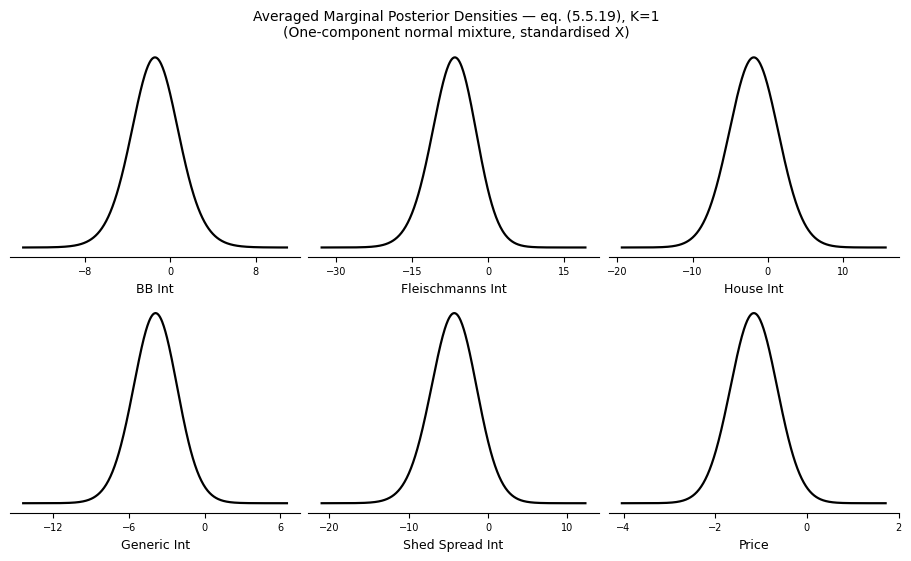

In [51]:
# ── 4. Plot — Figure 5.6 style ────────────────────────────────────────────────
 
plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]
 
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(9, 5.5),
    constrained_layout=True
)
 
for idx, ax in enumerate(axes.flat):
    ax.plot(grids[idx], densities[idx], color='black', linewidth=1.6)
 
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))
 
fig.suptitle(
    'Averaged Marginal Posterior Densities — eq. (5.5.19), K=1\n'
    '(One-component normal mixture, standardised X)',
    fontsize=10
)
 
plt.show()